In [3]:
import numpy as np
import tensorflow as tf
from keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [4]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)
class_name = validation_set.class_names
print(class_name)

Found 17572 files belonging to 38 classes.
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Tw

In [5]:
cnn = tf.keras.models.load_model('trained_plant_disease_model.keras')

In [6]:
import numpy as np
import cv2

print(np.__version__)
print(cv2.__version__)

1.23.5
4.8.1


In [7]:
import os
print(os.path.exists('test/test/AppleCedarRust1.JPG'))

True


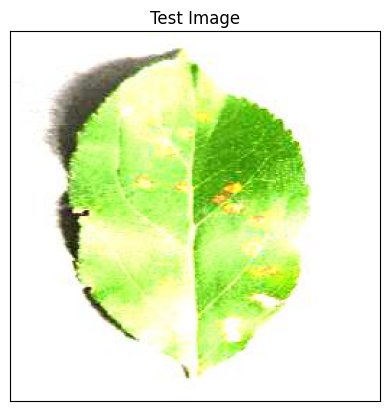

In [12]:
#Test Image Visualization

import cv2
import matplotlib.pyplot as plt

image_path = r"C:\Users\lokes\OneDrive\Desktop\Plant_Disease_Dataset\test\test\AppleCedarRust1.JPG"

# Read image
img = cv2.imread(image_path)

# Check if image loaded
if img is None:
    print("Image not found!")
else:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img)
    plt.title('Test Image')
    plt.xticks([])
    plt.yticks([])
    plt.show()

In [13]:
image = tf.keras.preprocessing.image.load_img(image_path,target_size=(128,128))
input_arr = tf.keras.preprocessing.image.img_to_array(image)
input_arr = np.array([input_arr])  # Convert single image to a batch.
predictions = cnn.predict(input_arr)

1/1 [==============================] - 8s 8s/step


In [14]:
print(predictions)

[[4.7999905e-17 1.5412147e-16 1.0000000e+00 6.5279453e-20 4.2528809e-13
  5.7117295e-14 1.6629292e-20 6.5463375e-16 3.5080091e-19 1.2368045e-17
  5.0707133e-23 1.0824092e-15 8.2824437e-18 2.4018175e-20 4.0521692e-18
  3.3740618e-16 5.3300178e-16 7.8047961e-20 2.0071280e-15 5.6854281e-17
  1.1666919e-20 5.1300039e-20 1.8225948e-16 5.0306541e-17 7.9014021e-21
  3.4685019e-19 1.0300563e-15 1.3869411e-19 3.1592068e-13 1.0236563e-14
  5.2160283e-13 3.5265920e-19 3.9957316e-16 1.4142104e-18 3.6827996e-14
  1.0106681e-13 3.0902443e-15 8.8000205e-17]]


In [15]:
result_index = np.argmax(predictions) #Return index of max element
print(result_index)

2


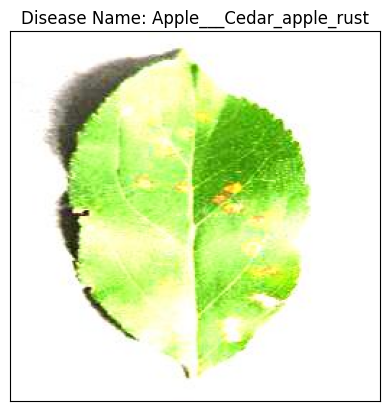

In [16]:
# Displaying the disease prediction
model_prediction = class_name[result_index]
plt.imshow(img)
plt.title(f"Disease Name: {model_prediction}")
plt.xticks([])
plt.yticks([])
plt.show()